## Лабораторная работа № 2 
## Машинное обучение на больших данных с использованием фреймворка Apache Spark и библиотеки SparkML

### Часть 1

В данной части работы рассмотрены:
* подготовка признаков для рашения задачи **линейной регрессии**;
* создание и обучение модели линейной регрессии;
* оценка качества модели.

#### Запуск `Spark`-сессии

Подключаем необходимые библиотеки.

In [1]:
import os
import csv
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, MinMaxScaler, Binarizer, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, CrossValidatorModel, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType
import seaborn as sns
import matplotlib.pyplot as plt

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    # Получаем имя пользователя
    # Получаем имя пользователя
    user_name = os.getenv("USER")
    
    conf = SparkConf()
    conf.setAppName("lab 1 Test")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    conf.set("spark.executor.memory", "12g")
    conf.set("spark.executor.cores", "6")
    conf.set("spark.executor.instances", "1")
    conf.set("spark.driver.memory", "4g")
    conf.set("spark.driver.cores", "1")

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

#### Загрузка датасета

In [5]:
df = spark.read.parquet("sobd_lab1_table_parquet")

Выведем прочитанную таблицу на экран.

In [6]:
df.show()

+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+------------+--------------+
|        id|               title|             authors|           publisher|      published_date|          categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|       authors_array|    categories_array|author_count|category_count|
+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+-----------

Анализ отзывов и рейтингов
| Название столбца | Расшифровка |
| -------- | ------ |
| id |	Уникальный идентификатор книги (ISBN/ASIN)
| title	| Название книги
| review_score	| Оценка книги пользователем (1.0-5.0)
| review_text	| Текст отзыва
| review_summary	| Заголовок отзыва
| review_helpfulness	| Полезность отзыва (в формате "X/Y")
| review_time	| Временная метка отзыва

Анализ книг и метаданных
| Название столбца | Расшифровка |
| -------- | ------ |
| authors	| Авторы книги
| publisher	| Издательство
| published_date	| Дата публикации книги
| categories	| Категории/жанры книги

Вспомним схему данных.

In [7]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- published_date: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- profile_name: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- authors_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- categories_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- author_count: integer (nullable = true)
 |-- category_count: integer (nullable = true)



Вычислим количество строк в датафрейме.

In [8]:
df.count()

221989

#### Постановка задачи линейной регрессии

Для датасета, заданного представленными колонками, требуется построить модель линейной регрессии для оценки **оценка отзыва** по всем остальным признакам. 

Для оценки качества обучения следует использовать метрики $RMSE$ и $R^2$.

#### Подготовка и кодирование признаков

Для корректной работы трансформеров преобразуем столбец `review_score` к типу `DoubleType`.

In [9]:
df = df.withColumn("review_score", col("review_score").cast(DoubleType()))

Создание бинарных данных

In [10]:
# Создаем бинарные признаки
from pyspark.sql.functions import when

# Бинаризация helpfulness_ratio
df = df.withColumn("is_helpful", 
    when(col("helpfulness_ratio") > 0.5, 1).otherwise(0))

# Бинаризация author_count
df = df.withColumn("has_multiple_authors",
    when(col("author_count") > 1, 1).otherwise(0))

# Бинаризация category_count
df = df.withColumn("has_multiple_categories",
    when(col("category_count") > 2, 1).otherwise(0))

# Бинаризация review_time (используем реалистичный порог)
# Найдем 75-й перцентиль для review_time
review_time_threshold = df.approxQuantile("review_time", [0.75], 0.01)[0]
df = df.withColumn("is_recent_review",
    when(col("review_time") > review_time_threshold, 1).otherwise(0))

Отделим от датасета некоторую часть объёмом примерно 1000 строк, и сохраним её на диске как локальный `csv`-файл. Он понадобится в следующей лабораторной работе.

In [11]:
def save_sample_to_csv(data: DataFrame, file_path: str, 
                       sample_size: int = 1000) -> DataFrame:
    """
    Сохраняет первые `sample_size` строк из DataFrame в CSV-файл 
    на драйвере и возвращает DataFrame с оставшимися данными.

    Args:
        data (DataFrame): DataFrame, из которого нужно извлечь
            строки.
        file_path (str): Путь для сохранения CSV-файла.
        sample_size (int): Количество строк для сохранения
            (по умолчанию 1000).

    Returns:
        DataFrame: DataFrame с оставшимися данными.
    """
    # Определяем пропорции для разделения
    sample_fraction = sample_size / data.count()
    remaining_fraction = 1 - sample_fraction

    # Разделяем DataFrame на два непересекающихся набора данных
    sample_data, remaining_data = data.randomSplit(
        [sample_fraction, remaining_fraction]
    )

    # Сохраняем извлеченные строки в CSV-файл на драйвере
    try:
        with open(file_path, mode="w", newline="") as file:
            writer = csv.writer(file)

            # Записываем заголовок
            writer.writerow(data.columns)

            # Записываем строки
            for row in sample_data.take(sample_size):
                writer.writerow(row)
        print(f"Файл \"{file_path}\" с данными успешно создан.")

    except Exception as e:
        print(f"Ошибка при записи файла: {e}")

    return remaining_data

Определяем путь для сохранения `csv`-файла.

In [12]:
path = "streaming-data.csv"

df = save_sample_to_csv(data=df, file_path=path, sample_size=1000)

Файл "streaming-data.csv" с данными успешно создан.


Оцениваем, сколько строк в датасете осталось.

In [13]:
df.count()

220998

Разделим датасет на обучающую и тестовую выборки.

In [14]:
train_df, test_df = df.randomSplit([0.8, 0.2])

In [15]:
print(f"Train dataset size: {train_df.count()}")
print(f"Test  dataset size: {test_df.count()}")

Train dataset size: 177156
Test  dataset size: 43842


Понятно, что идентификационные признаки (id, user_id) и текстовые мета-признаки (profile_name, review_helpfulness) не оказывают прямого влияния на рейтинг книги. Использовать их в модели нет смысла.

Также производные признаки (published_date_clean, authors_array, categories_array) дублируют информацию из других признаков, поэтому их также исключим из модели.о их типу:

* **Категориальные** признаки не содержат большого количества категорий, закодируем их `one-hot`-кодировкой.
* **Бинарные** признаки представлены значениями `true` / `false`, которые могут быть интерпретированы как единица и нуль. Поэтому, в кодировании не нуждаются.
* **Количественные** признаки нужно нормализовать / стандартизировать, перед тем, как передавать их в модель.
* Среди количественных признаков выделяется `mileage`, который по своим значениям больше напоминает бинарный. **Бинаризуем** его по порогу `100`.

In [16]:
# Обновляем признаки на основе вашей структуры данных
categorical_features = [
    "publisher",     # издательство книги
    "categories"     # жанры/категории книги
]

binary_features = [
    "is_helpful",           # бинаризованный helpfulness_ratio (> 0.5)
    "has_multiple_authors", # author_count > 1
    "has_multiple_categories", # category_count > 2
    "is_recent_review"      # review_time > 75-го перцентиля
]

# Числовые признаки (все доступные числовые столбцы)
numeric_features = [
    "review_time", 
    "helpfulness_numerator",
    "helpfulness_denominator", 
    "helpfulness_ratio",
    "author_count", 
    "category_count"
]

# Текстовые признаки (исключаем из модели, но перечисляем для полноты)
text_features = [
    "title",           # название книги
    "authors",         # авторы книги
    "review_text",     # текст отзыва
    "review_summary",  # краткое содержание отзыва
    "published_date"   # дата публикации (текстовый формат)
]

# Признаки, которые не используем в модели
non_predictive_features = [
    "id",                    # уникальный идентификатор
    "user_id",              # идентификатор пользователя
    "profile_name",         # имя пользователя
    "review_helpfulness",   # сырая строка полезности
    "authors_array",        # массив авторов (дублирует author_count)
    "categories_array"      # массив категорий (дублирует category_count)
]

print("✅ Признаки успешно определены:")
print(f"Категориальные: {categorical_features}")
print(f"Бинарные: {binary_features}")
print(f"Числовые: {numeric_features}")
print(f"Текстовые (не используются): {text_features}")
print(f"Исключенные: {non_predictive_features}")

✅ Признаки успешно определены:
Категориальные: ['publisher', 'categories']
Бинарные: ['is_helpful', 'has_multiple_authors', 'has_multiple_categories', 'is_recent_review']
Числовые: ['review_time', 'helpfulness_numerator', 'helpfulness_denominator', 'helpfulness_ratio', 'author_count', 'category_count']
Текстовые (не используются): ['title', 'authors', 'review_text', 'review_summary', 'published_date']
Исключенные: ['id', 'user_id', 'profile_name', 'review_helpfulness', 'authors_array', 'categories_array']


Создадим конвейер обработки данных, включающий модель линейной регрессии.

In [17]:
def create_pipeline(categorical_features: list[str], 
                   numeric_features: list[str],
                   binary_features: list[str],
                   label_col: str, 
                   max_iter: int = 100) -> Pipeline:
    """Создает конвейер для линейной регрессии без published_year"""
    
    stages = []
    
    # 1. Категориальные признаки
    if categorical_features:
        indexed_categorical = [f"{feature}_index" for feature in categorical_features]
        onehot_categorical = [f"{feature}_ohe" for feature in categorical_features]
        
        string_indexer = StringIndexer(
            inputCols=categorical_features,
            outputCols=indexed_categorical,
            handleInvalid="keep"
        )
        onehot_encoder = OneHotEncoder(
            inputCols=indexed_categorical,
            outputCols=onehot_categorical,
            dropLast=True,
            handleInvalid="keep"
        )
        stages.extend([string_indexer, onehot_encoder])
    
    # 2. Числовые признаки
    if numeric_features:
        vector_num_assembler = VectorAssembler(
            inputCols=numeric_features,
            outputCol="numeric_vector"
        )
        numeric_scaler = StandardScaler(
            inputCol="numeric_vector",
            outputCol="numeric_vector_scaled",
            withStd=True,
            withMean=True
        )
        stages.extend([vector_num_assembler, numeric_scaler])
    
    # 3. Сбор всех признаков
    feature_cols = []
    if categorical_features:
        feature_cols.extend(onehot_categorical)
    feature_cols.extend(binary_features)
    if numeric_features:
        feature_cols.append("numeric_vector_scaled")
    
    vector_all_assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol="features"
    )
    stages.append(vector_all_assembler)
    
    # 4. Линейная регрессия
    linear_regression = LinearRegression(
        featuresCol="features",
        labelCol=label_col,
        predictionCol="prediction",
        standardization=False,
        maxIter=max_iter,
        regParam=0.01
    )
    stages.append(linear_regression)
    
    return Pipeline(stages=stages)

In [18]:

print("Используемые признаки:")
print(f"Категориальные: {categorical_features}")
print(f"Числовые: {numeric_features}")
print(f"Бинарные: {binary_features}")

# Создаем конвейер с правильными параметрами
pipeline = create_pipeline(
    categorical_features=categorical_features,
    numeric_features=numeric_features,
    binary_features=binary_features,
    label_col="review_score",
    max_iter=15
)

print("✅ Конвейер успешно создан!")

Используемые признаки:
Категориальные: ['publisher', 'categories']
Числовые: ['review_time', 'helpfulness_numerator', 'helpfulness_denominator', 'helpfulness_ratio', 'author_count', 'category_count']
Бинарные: ['is_helpful', 'has_multiple_authors', 'has_multiple_categories', 'is_recent_review']
✅ Конвейер успешно создан!


#### Обучение модели

Выполним **подбор гиперпараметров** модели линейной регрессии с помощью кросс-валидации на сетке.

Создаем сетку параметров для кросс-валидации, получив объект `LinearRegression` из конвейера.

In [19]:
param_grid = ParamGridBuilder() \
    .addGrid(pipeline.getStages()[-1].regParam, [0.01, 0.1, 1.0]) \
    .addGrid(pipeline.getStages()[-1].elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

Создаем экземпляр `RegressionEvaluator` для оценки модели.

In [20]:
cv_evaluator = RegressionEvaluator(labelCol="review_score",
                                   predictionCol="prediction", 
                                   metricName="rmse")

Создаем объект `CrossValidator`.

In [21]:
cross_validator = CrossValidator(estimator=pipeline,
                                 estimatorParamMaps=param_grid,
                                 evaluator=cv_evaluator,
                                 numFolds=5)

Обучаем модель конвейера с использованием кросс-валидации.

In [22]:
cv_model = cross_validator.fit(train_df)

Выведем параметры **лучшей** модели, определенной в ходе кросс-валидации.

In [23]:
def get_best_model_params(cv_model: CrossValidatorModel) -> dict[str, float]:
    """
    Получает параметры лучшей модели из объекта CrossValidatorModel.

    Args:
        cv_model (CrossValidatorModel): Объект CrossValidatorModel, 
            содержащий лучшую модель.

    Returns:
        Dict[str, float]: Параметры лучшей модели.
    """
    best_model = cv_model.bestModel
    best_params = {
        "regParam": best_model.stages[-1].getRegParam(),
        "elasticNetParam": best_model.stages[-1].getElasticNetParam(),
        "maxIter": best_model.stages[-1].getMaxIter()
    }
    return best_params

In [24]:
for key, value in get_best_model_params(cv_model=cv_model).items():
    print(f"{key}: {value}")

regParam: 0.01
elasticNetParam: 0.5
maxIter: 15


#### Анализ процесса обучения

Визуализируем изменение ошибки модели в ходе обучения и рассчитаем метрики на обучающем датасете.

In [25]:
def plot_training_summary(cv_model: DataFrame) -> None:
    """
    Отображает графики зависимости значения ошибки от номера итерации на
    обучающей выборке, а также значения метрик RMSE и R^2.

    Args:
        cv_model (DataFrame): Обученная модель с использованием кросс-валидации.
    """
    # Получаем лучшую модель
    best_model = cv_model.bestModel

    # Получаем информацию о процессе обучения
    training_summary = best_model.stages[-1].summary

    # Получаем значения ошибки для каждой итерации
    objective_history = training_summary.objectiveHistory

    # Строим график зависимости значения ошибки от номера итерации
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=range(len(objective_history)), 
                 y=objective_history, 
                 marker='o')
    plt.xlabel('Итерация')
    plt.ylabel('Ошибка')
    plt.title("Зависимость значения функции ошибки от номера итерации")

    # Получаем значения метрик
    rmse = training_summary.rootMeanSquaredError
    r2 = training_summary.r2

    # Добавляем значения метрик на график
    plt.text(0.95, 0.95, f"RMSE: {rmse:.2f}\nR^2: {r2:.2f}",
             transform=plt.gca().transAxes, ha='right', va='top',
             bbox=dict(facecolor='white', alpha=0.8), zorder=5)
    plt.grid()

    plt.show()

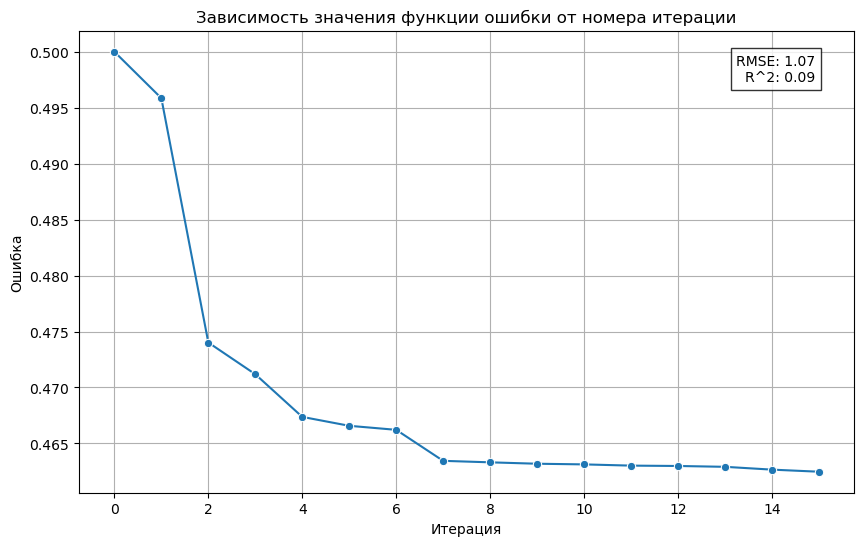

In [26]:
plot_training_summary(cv_model)

#### Проверка обобщающей способности модели

Выполним предсказания на тестовой выборке. 

Перегруппируем колонки датафрейма, переставив столбец с ценой автомобиля в конец, чтобы его значения было удобно сравнивать с предсказанными.

In [27]:
# Получаем датасет предсказаний
test_df_predictions = cv_model.transform(test_df)

# Извлекаем список колонок, устанавливаем цену на последнее место
right_columns_order = test_df_predictions.columns
right_columns_order.remove("review_score")
right_columns_order.append("review_score")

# Изменяем последовательность колонок и выводим датафрейм
test_df_predictions = test_df_predictions.select(*right_columns_order)
test_df_predictions.show()

+----------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+------------+--------------+----------+--------------------+-----------------------+----------------+---------------+----------------+--------------------+--------------------+--------------------+---------------------+--------------------+------------------+------------+
|        id|               title|             authors|           publisher|      published_date|          categories|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|       authors_array|    categories_array|author_count|category_count|is_helpful|has_multiple_authors|h

Создадим функцию оценки модели: расчета метрик для некоторого датасета, как правило, тестового.

In [28]:
def evaluate_model(data: DataFrame, metric_name: str) -> float:
    """
    Оценивает модель с использованием указанной метрики.

    Args:
        data (DataFrame): DataFrame, содержащий предсказания и фактические метки.
        metric_name (str): Название метрики для оценки (например, "rmse", "r2").

    Returns:
        float: Значение указанной метрики.
    """
    evaluator = RegressionEvaluator(labelCol="review_score", 
                                    predictionCol="prediction", 
                                    metricName=metric_name)
    metric_value = evaluator.evaluate(data)
    return metric_value

Оценим модель на тестовой выборке.

In [29]:
test_rmse = evaluate_model(test_df_predictions, "rmse")
test_r2 = evaluate_model(test_df_predictions, "r2")

print(f"RMSE on test data: {test_rmse:.2f}")
print(f"R^2 on test data: {test_r2:.2f}")

RMSE on test data: 1.07
R^2 on test data: 0.09


Метрики весьма неплохие для линейной модели!

#### Сохранение модели

Зададим директорию, в которой будет сохранена обученная модель.

In [30]:
# Путь модели
model_path = f"lr-model"

# Сохраняем модель конвейера в HDFS
try:
    cv_model.bestModel.save(model_path)
    print(f"Модель успешно сохранена в \"{model_path}\"")
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")


Модель успешно сохранена в "lr-model"


Не забываем завершать `Spark`-сессию.

In [31]:
spark.stop()